In [269]:
import os
from tifffile import imread, imwrite
from skimage.measure import regionprops
from scipy.ndimage import find_objects
import numpy as np
import nd2
import pandas as pd

from scipy.ndimage import affine_transform
from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt

from tqdm.notebook import trange, tqdm

import seaborn as sns
import plotly.express as px
import dask.array as da

from scipy.stats import iqr

from contextlib import redirect_stdout

In [59]:
def get_props(lbl):
    objects = find_objects(lbl)
    
    for i, sl in enumerate(objects, 1):
        if sl is None: continue
        mask = lbl[sl] == i
        if mask.sum() < 30:
            imprint = lbl[sl]
            imprint[mask] = 0
            lbl[sl] = imprint
    
    props = regionprops(lbl)
    parameters = [
        "label",
        #"eccentricity",
        "axis_major_length",
        "axis_minor_length",
        "area",
        #"solidity",
        #"perimeter",
    ]
    values = {v: [] for v in parameters}
    for p in props:
        try:
            tmp = {v: p[v] for v in parameters}
        except ValueError:
            print("Skipping lbl_id", p["label"])
            continue
        for v in parameters:
            values[v].append(tmp[v])

    df = pd.DataFrame(values)
    df["aspect ratio"] = df["axis_major_length"] / df["axis_minor_length"]
    return df

In [3]:
def get_melt_df(img, lbl0, lbl1):
    df0 = calc_df(img[0], lbl0)
    df1 = calc_df(img[1], lbl1)
    
    props_df0 = get_props(lbl0)
    props_df1 = get_props(lbl1)
    props_df = props_df0.merge(props_df1, left_on="label", right_on="label", suffixes=("_0", "_1"))

    dfs = []
    for i in ["ratio", "gfp", "mScarlet"]:
        tmp0 = df0.loc[df0["type"] == i, ["median", "lbl_id"]]
        tmp1 = df1.loc[df1["type"] == i, ["median", "lbl_id"]]
    
        merge = tmp0.merge(tmp1, left_on="lbl_id", right_on="lbl_id", suffixes=("_0", "_1"))
    
        merge = merge[merge["median_1"] > 0]
        merge = merge[merge["median_0"] > 0]
        
        merge["ratio"] = merge["median_1"] / merge["median_0"]
        merge["diff"] = merge["median_1"] - merge["median_0"]
    
        dfs.append(merge)

    df = dfs[0].merge(dfs[1], left_on="lbl_id", right_on="lbl_id", suffixes=("_ratio", "_gfp"))
    df = df.merge(dfs[2], left_on="lbl_id", right_on="lbl_id")
    df = df.merge(props_df, left_on="lbl_id", right_on="label")
    
    df = df[(df["aspect ratio_0"] > 2) & (df["aspect ratio_1"] > 2)]
    
    return df

In [36]:
def calc_assignment(lbl0, lbl1):
    cost_matrix = np.zeros((lbl0.max(), lbl1.max()), dtype=int)
    inds = np.logical_and(lbl0 > 0, lbl1 > 0)
    
    for i, j in zip(lbl0[inds]-1, lbl1[inds]-1):
        cost_matrix[i, j] += 1

    row_ind, col_ind = linear_sum_assignment(cost_matrix, maximize=True)
    return {int(k+1): int(v+1) for k, v in zip(col_ind, row_ind) if cost_matrix[v, k] > 10}


def reassign_lbls(lbl, assignment):
    new_lbl = np.zeros_like(lbl)
    for i, sl in enumerate(find_objects(lbl), 1):
        if sl is None: continue
        if i not in assignment: continue
        mask = lbl[sl] == i
        new_tmp = np.copy(new_lbl[sl])
        
        new_tmp[mask] = assignment[i]
        new_lbl[sl] = new_tmp
    return new_lbl

In [9]:
path = "/mnt/z/Dasha/2. FAST-AB biosensors/Microscope/Inverted bladder model/TrimFABS sensor 30.06.2026/To analyze"
lbl_filepath = os.path.join(path, "sciCORE", "nfmp_prob0.6", "2026_01_05_Dasha_ibm-02")

In [8]:
img_da = {}

file = "NCCRBM128_sample4.nd2"

files = [
    "NCCRBM128_sample4_before.nd2",
    "NCCRBM128_sample4_TMP.nd2",
]

imgs = [
    nd2.ND2File(os.path.join(path, file))
    for file in files
]

img_da["NCCRBM128_sample4"] = da.stack([img.to_dask() for img in imgs], axis=0)

file = "NCCRBM128_sample5.nd2"

nd2_file = nd2.ND2File(os.path.join(path, file))
img_da["NCCRBM128_sample5"] = nd2_file.to_dask()

file = "NCCRBM128_sample6.nd2"

nd2_file = nd2.ND2File(os.path.join(path, file))
img_da["NCCRBM128_sample6"] = nd2_file.to_dask()

/tmp/ipykernel_61473/2002173967.py:10: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  imgs = [


In [127]:
def get_lbl_img(name, pos):
    filename = f"{name}_pos{pos}_t{{t}}_mScarlett.tiff"
    
    lbl0 = imread(os.path.join(lbl_filepath, filename.format(t=0)))
    lbl1 = imread(os.path.join(lbl_filepath, filename.format(t=1)))

    img = img_da[name][:, pos, :, 1:].compute()

    aligned_lbls = imread(os.path.join(path, "padded-tif-files", f"{name}_pos{pos}_new_prob0.6.tif"))
    assignment = calc_assignment(aligned_lbls[0], aligned_lbls[1])
    reassigned_lbl1 = reassign_lbls(lbl1, assignment)
    
    return lbl0, reassigned_lbl1, img

In [201]:
def calc_ratios(values):
    means = np.concat((
        np.mean(values, axis=0)[np.newaxis, :],
        np.percentile(values, q=[50, 75, 90, 95], axis=0),
    ), axis=0)
    return np.concat((means[:, 1] / means[:, 0], means[:, 0], means[:, 1]))

value_vars = ["mean", "median", "75 %", "90 %", "95 %"]
def calc_df(img, lbl):
    lbl = lbl[:img.shape[0]]
    bg = np.median(img[lbl==0], axis=0)
    img = np.clip(img - bg, 1, None)
    
    objects = find_objects(lbl)

    values = []
    lbl_id = []
    for i, sl in enumerate(objects, 1):
        if sl is None: continue
        mask = lbl[sl] == i
        values.append(calc_ratios(img[sl][mask]))
        lbl_id.append(i)
    values_np = np.stack(values, axis=0)

    dfs = []
    for j, ty in enumerate(["ratio", "mScarlet", "gfp"]):
        values = {t: values_np[:, i+j*len(value_vars)] for i, t in enumerate(value_vars)}
        values["lbl_id"] = lbl_id
        values["type"] = ty
        dfs.append(pd.DataFrame(values))

    return pd.concat(dfs, ignore_index=True)

In [202]:
dfs = []
for sample in [4, 5, 6]:
    name = f"NCCRBM128_sample{sample}"
    for i in trange(4):
        if sample in [5, 6] and i == 0:
            continue
        lbl0, reassigned_lbl1, img = get_lbl_img(name, i)
        df = get_melt_df(img.transpose(0, 1, 3, 4, 2), lbl0, reassigned_lbl1)
        df["name"] = name
        df["pos"] = i
        dfs.append(df)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [203]:
all_df = pd.concat(dfs, ignore_index=True)
all_df["area ratio"] = all_df["area_1"] / all_df["area_0"]

In [204]:
df_melt = all_df.melt(id_vars=["lbl_id", "name", "pos"], value_vars=["ratio_ratio", "ratio_gfp", "ratio"])

In [205]:
all_df.columns

Index(['median_0_ratio', 'lbl_id', 'median_1_ratio', 'ratio_ratio',
       'diff_ratio', 'median_0_gfp', 'median_1_gfp', 'ratio_gfp', 'diff_gfp',
       'median_0', 'median_1', 'ratio', 'diff', 'label', 'axis_major_length_0',
       'axis_minor_length_0', 'area_0', 'aspect ratio_0',
       'axis_major_length_1', 'axis_minor_length_1', 'area_1',
       'aspect ratio_1', 'name', 'pos', 'area ratio'],
      dtype='object')

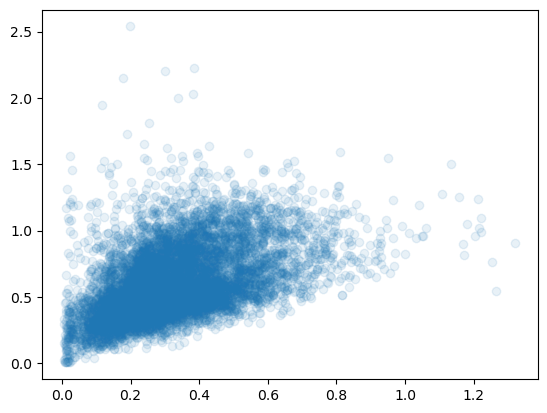

In [206]:
plt.scatter(all_df["median_0_ratio"], all_df["median_1_ratio"], alpha=0.1)

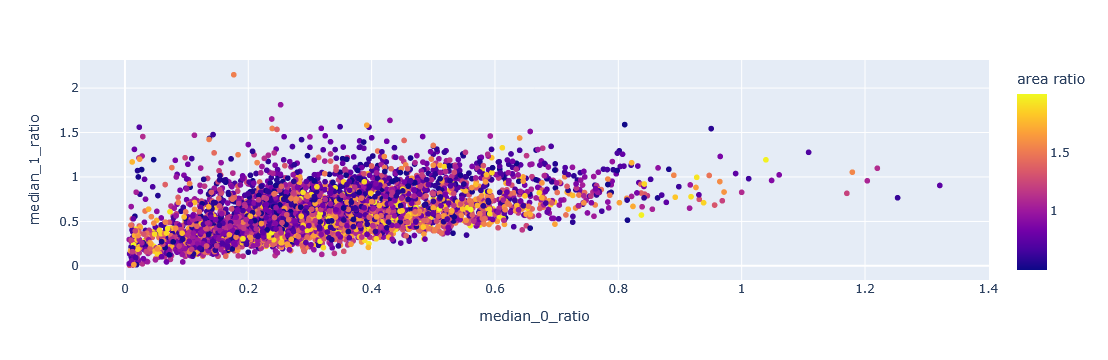

In [245]:
tmp_df = all_df[(0.5 < all_df["area ratio"]) & (all_df["area ratio"] < 2)]
#tmp_df = all_df

px.scatter(
    tmp_df,
    x="median_0_ratio",
    y="median_1_ratio",
    color="area ratio",
    hover_data=["label", "name", "pos"],
)

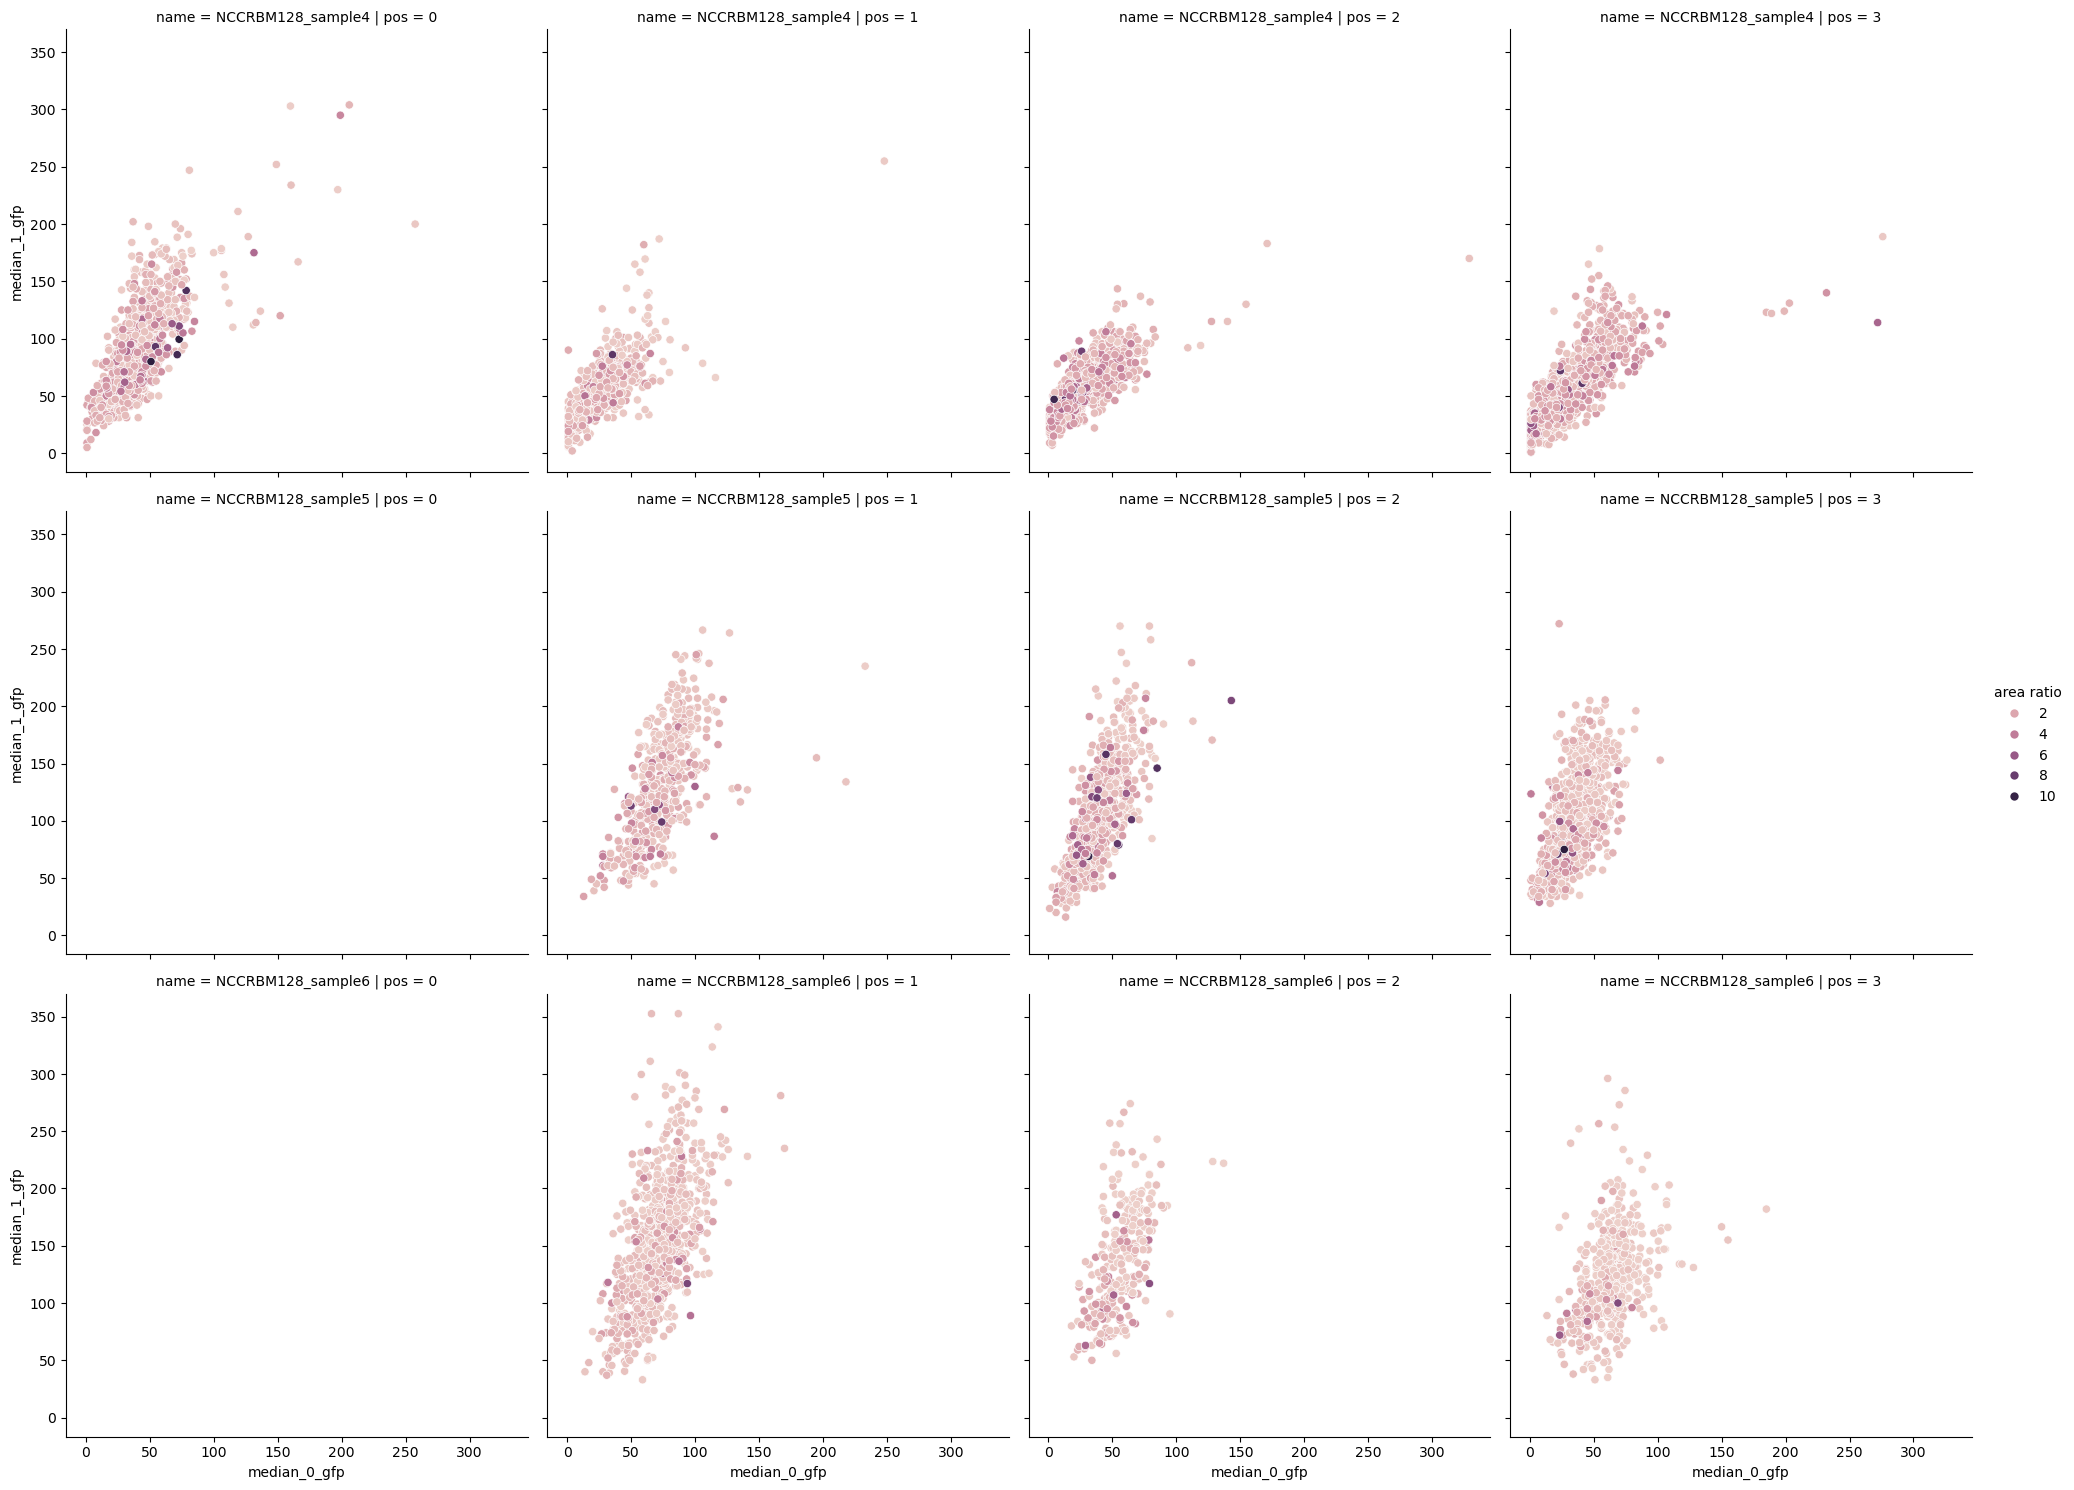

In [234]:
sns.relplot(
    tmp_df,
    x="median_0_gfp",
    y="median_1_gfp",
    hue="area ratio",
    row="name",
    col="pos",
)

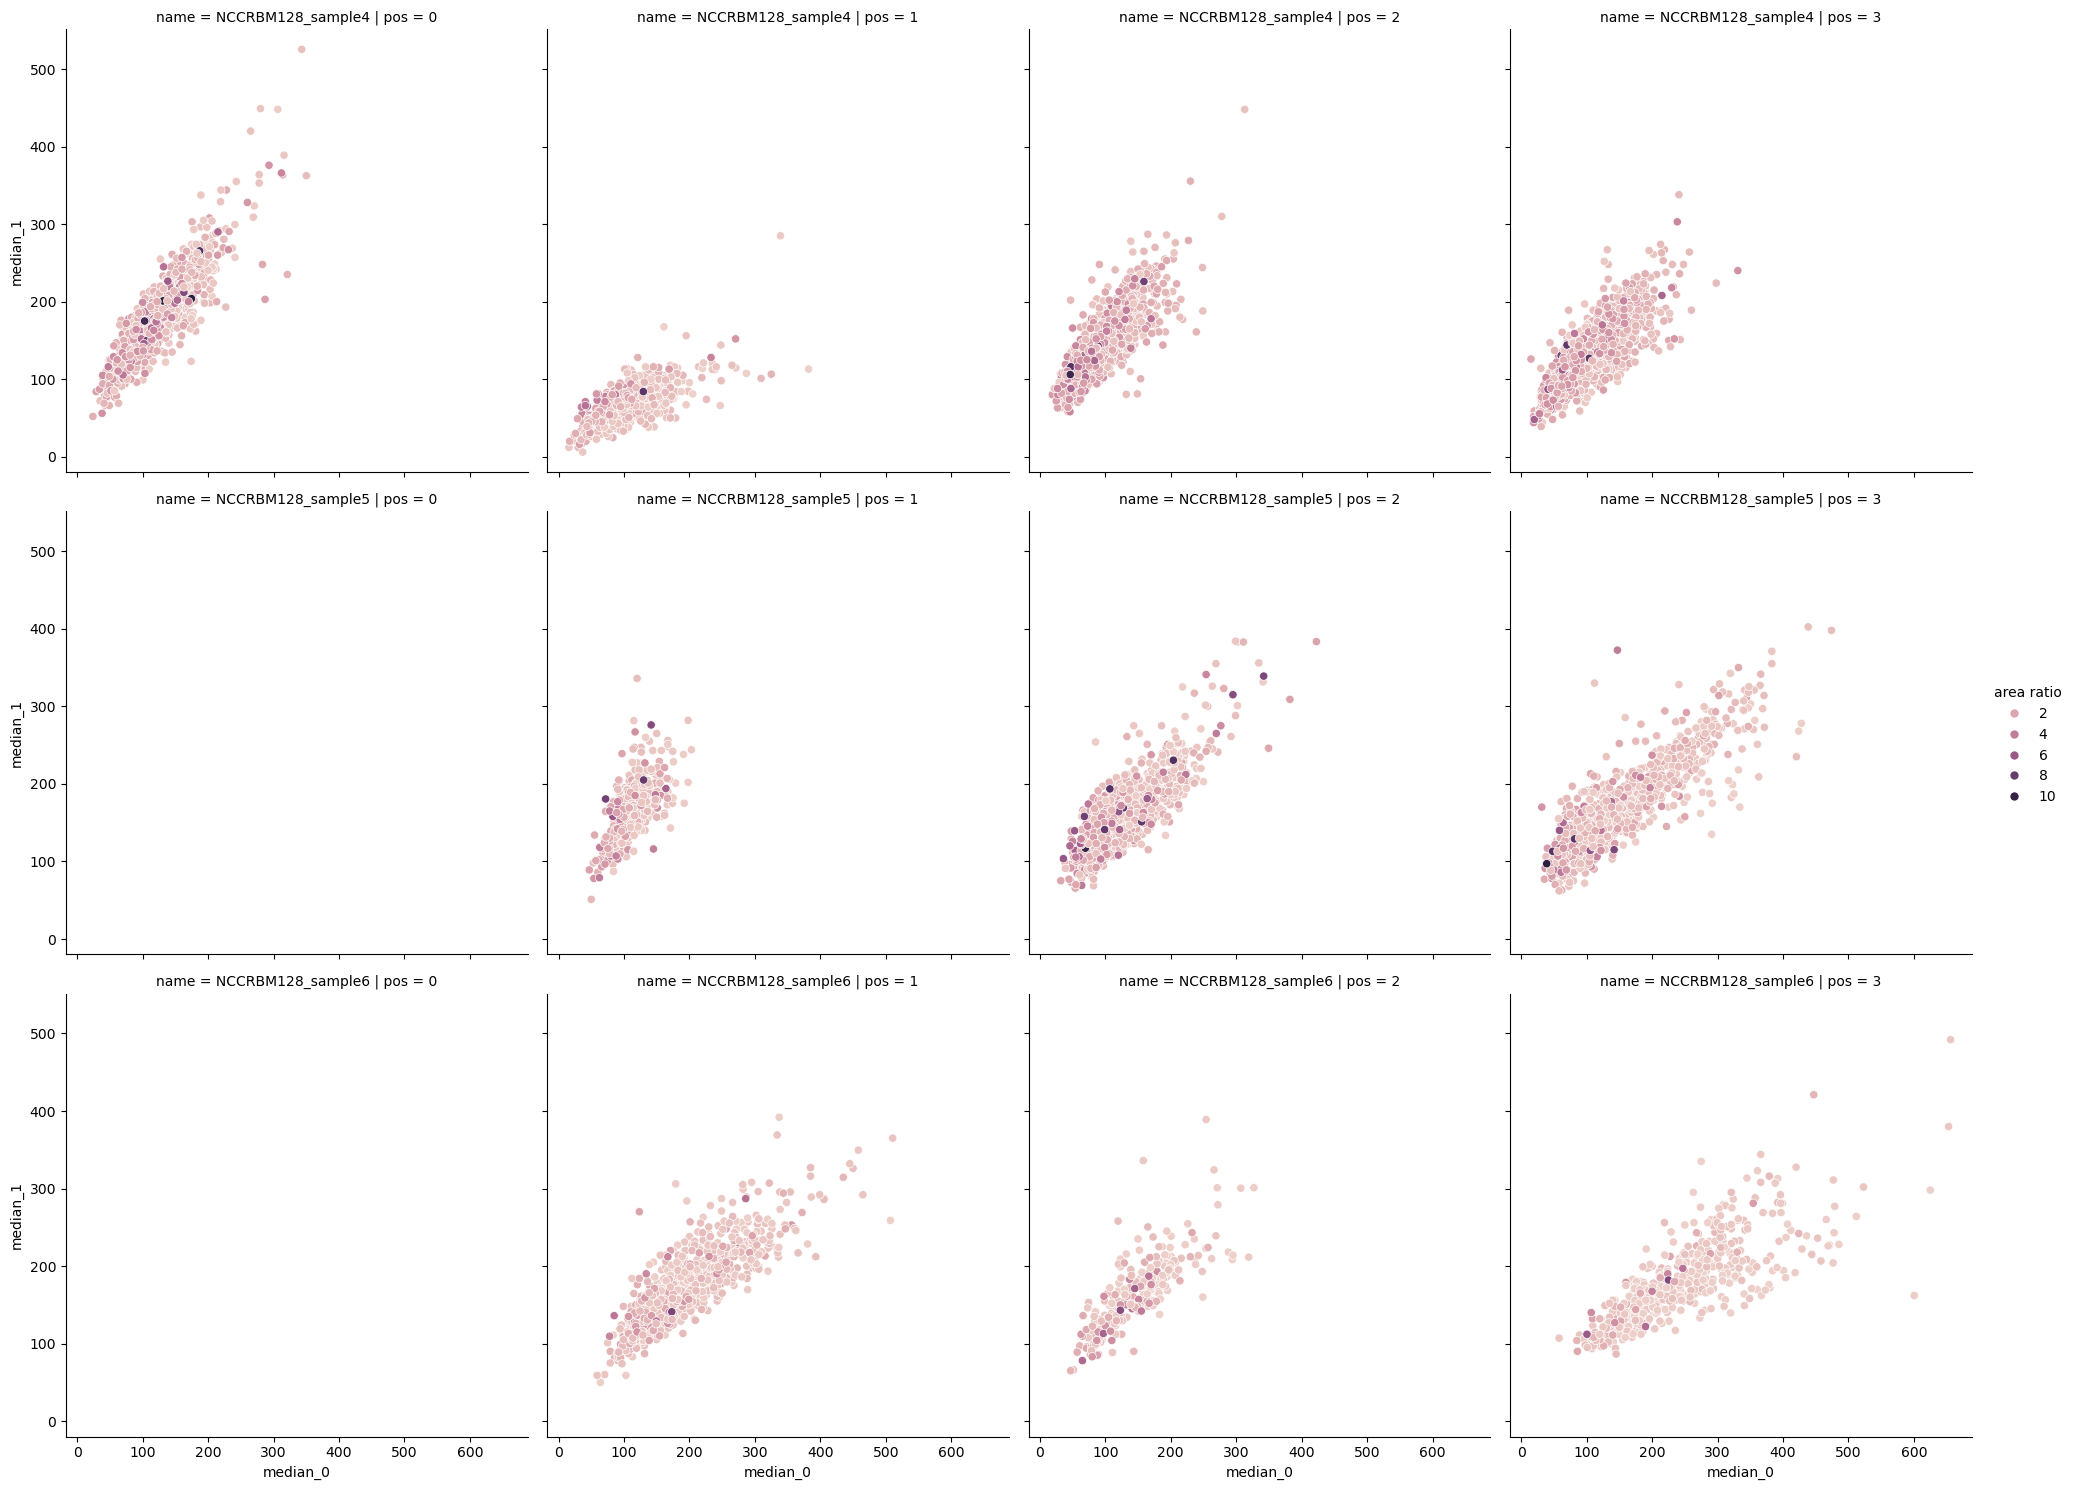

In [235]:
sns.relplot(
    tmp_df,
    x="median_0",
    y="median_1",
    hue="area ratio",
    row="name",
    col="pos",
)

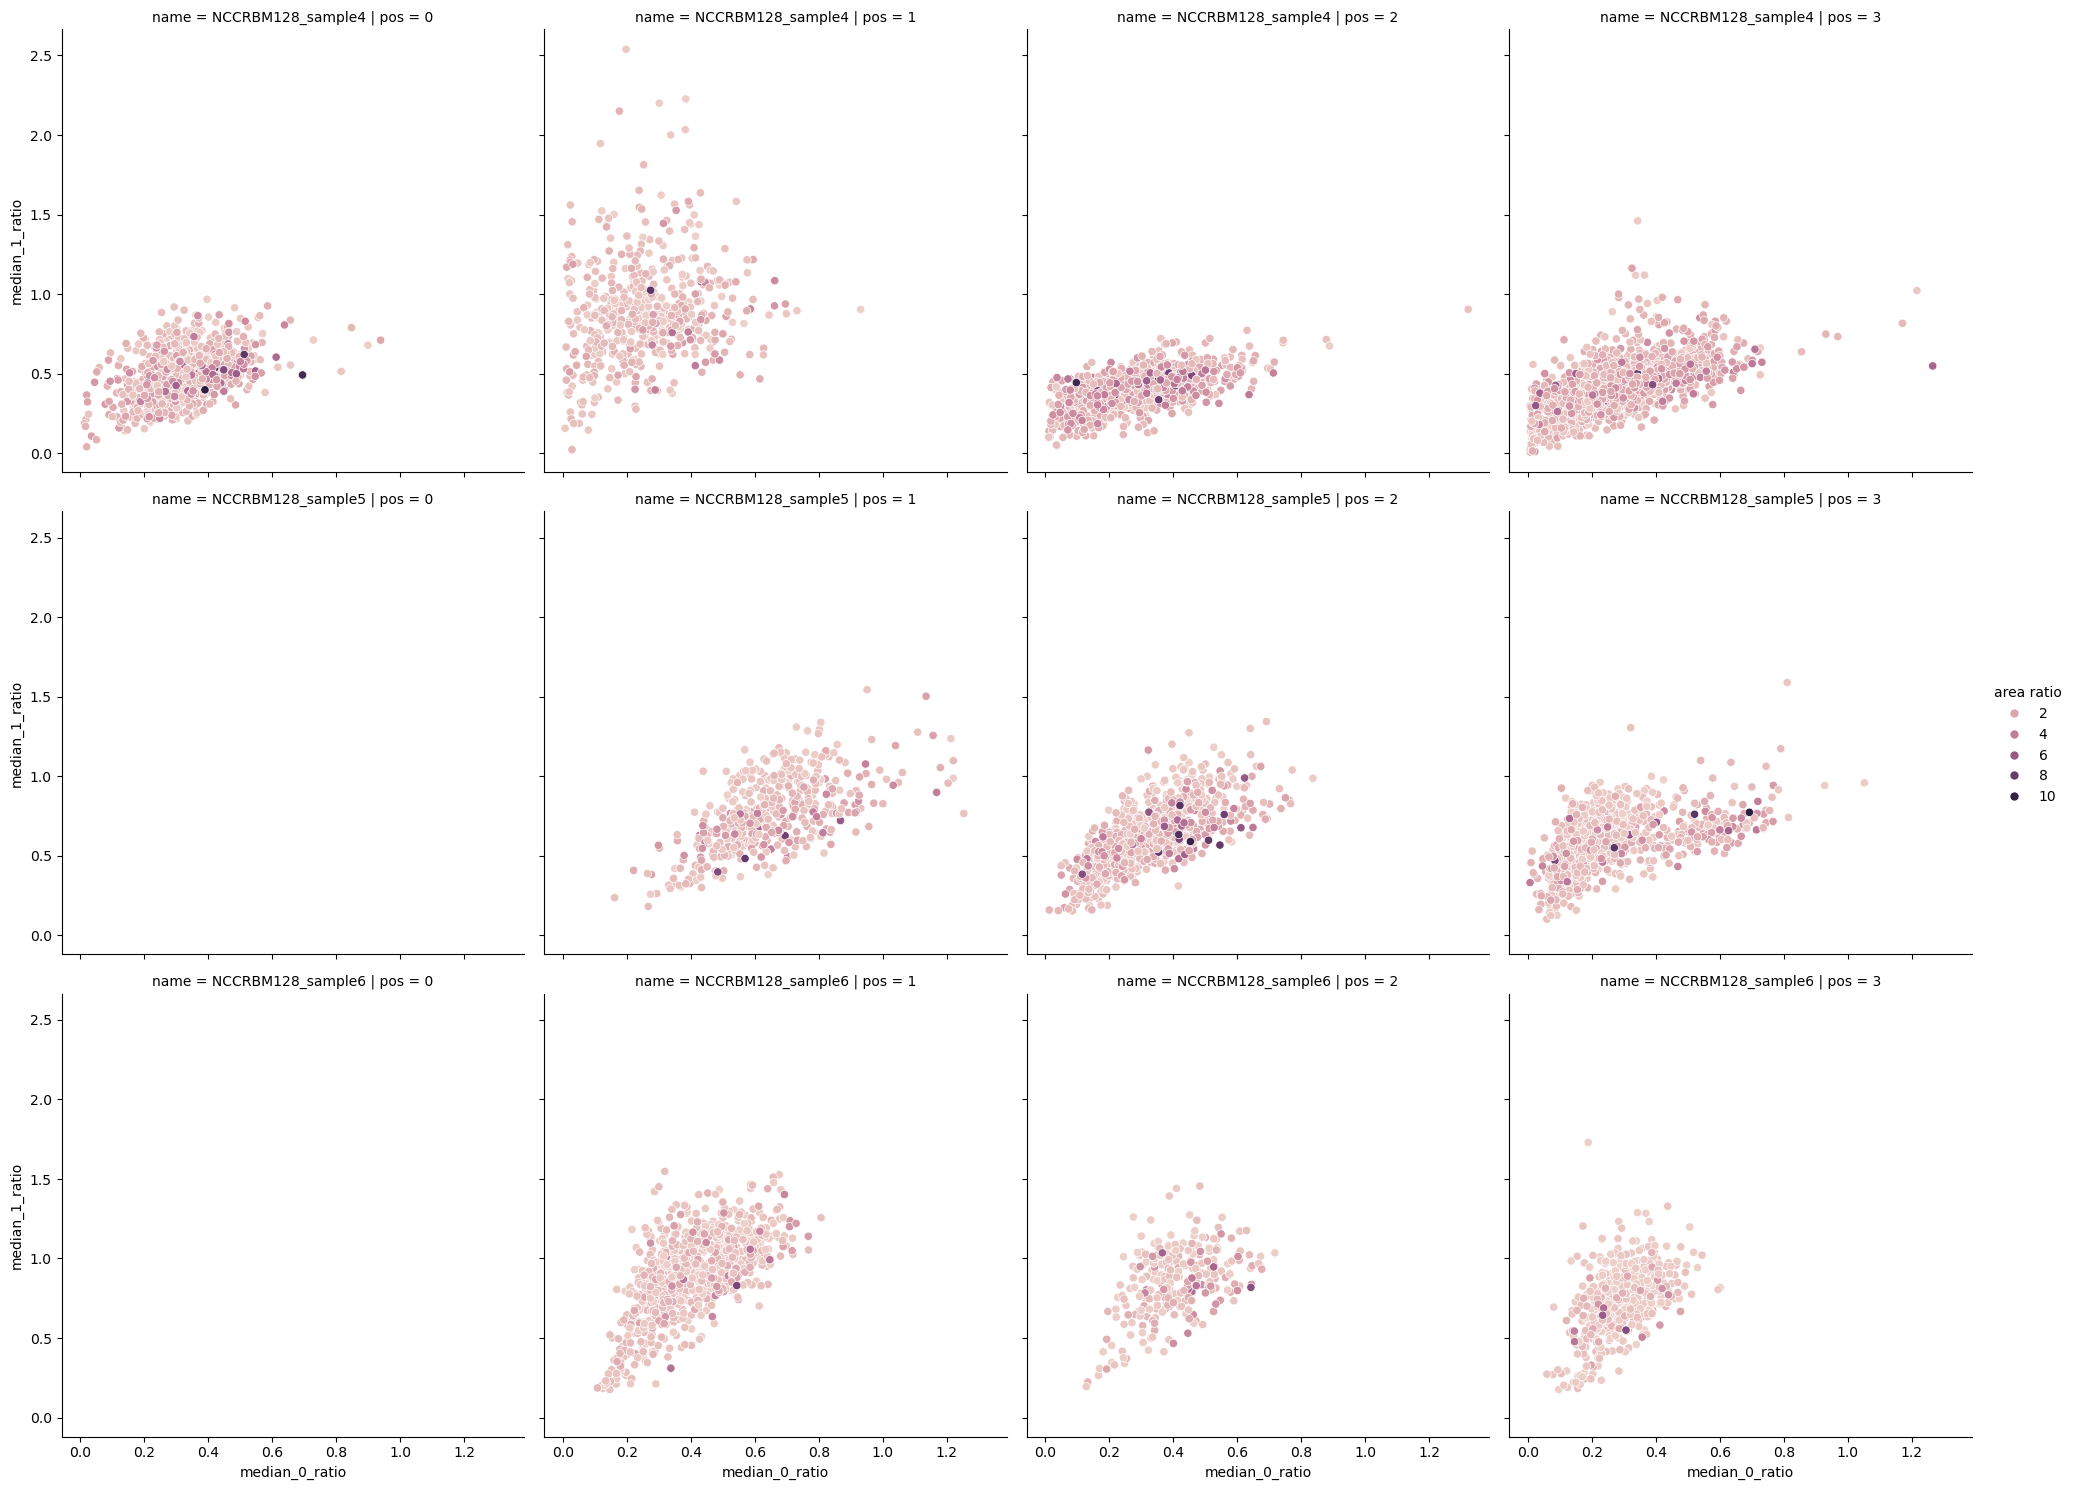

In [236]:
sns.relplot(
    tmp_df,
    x="median_0_ratio",
    y="median_1_ratio",
    hue="area ratio",
    row="name",
    col="pos",
)

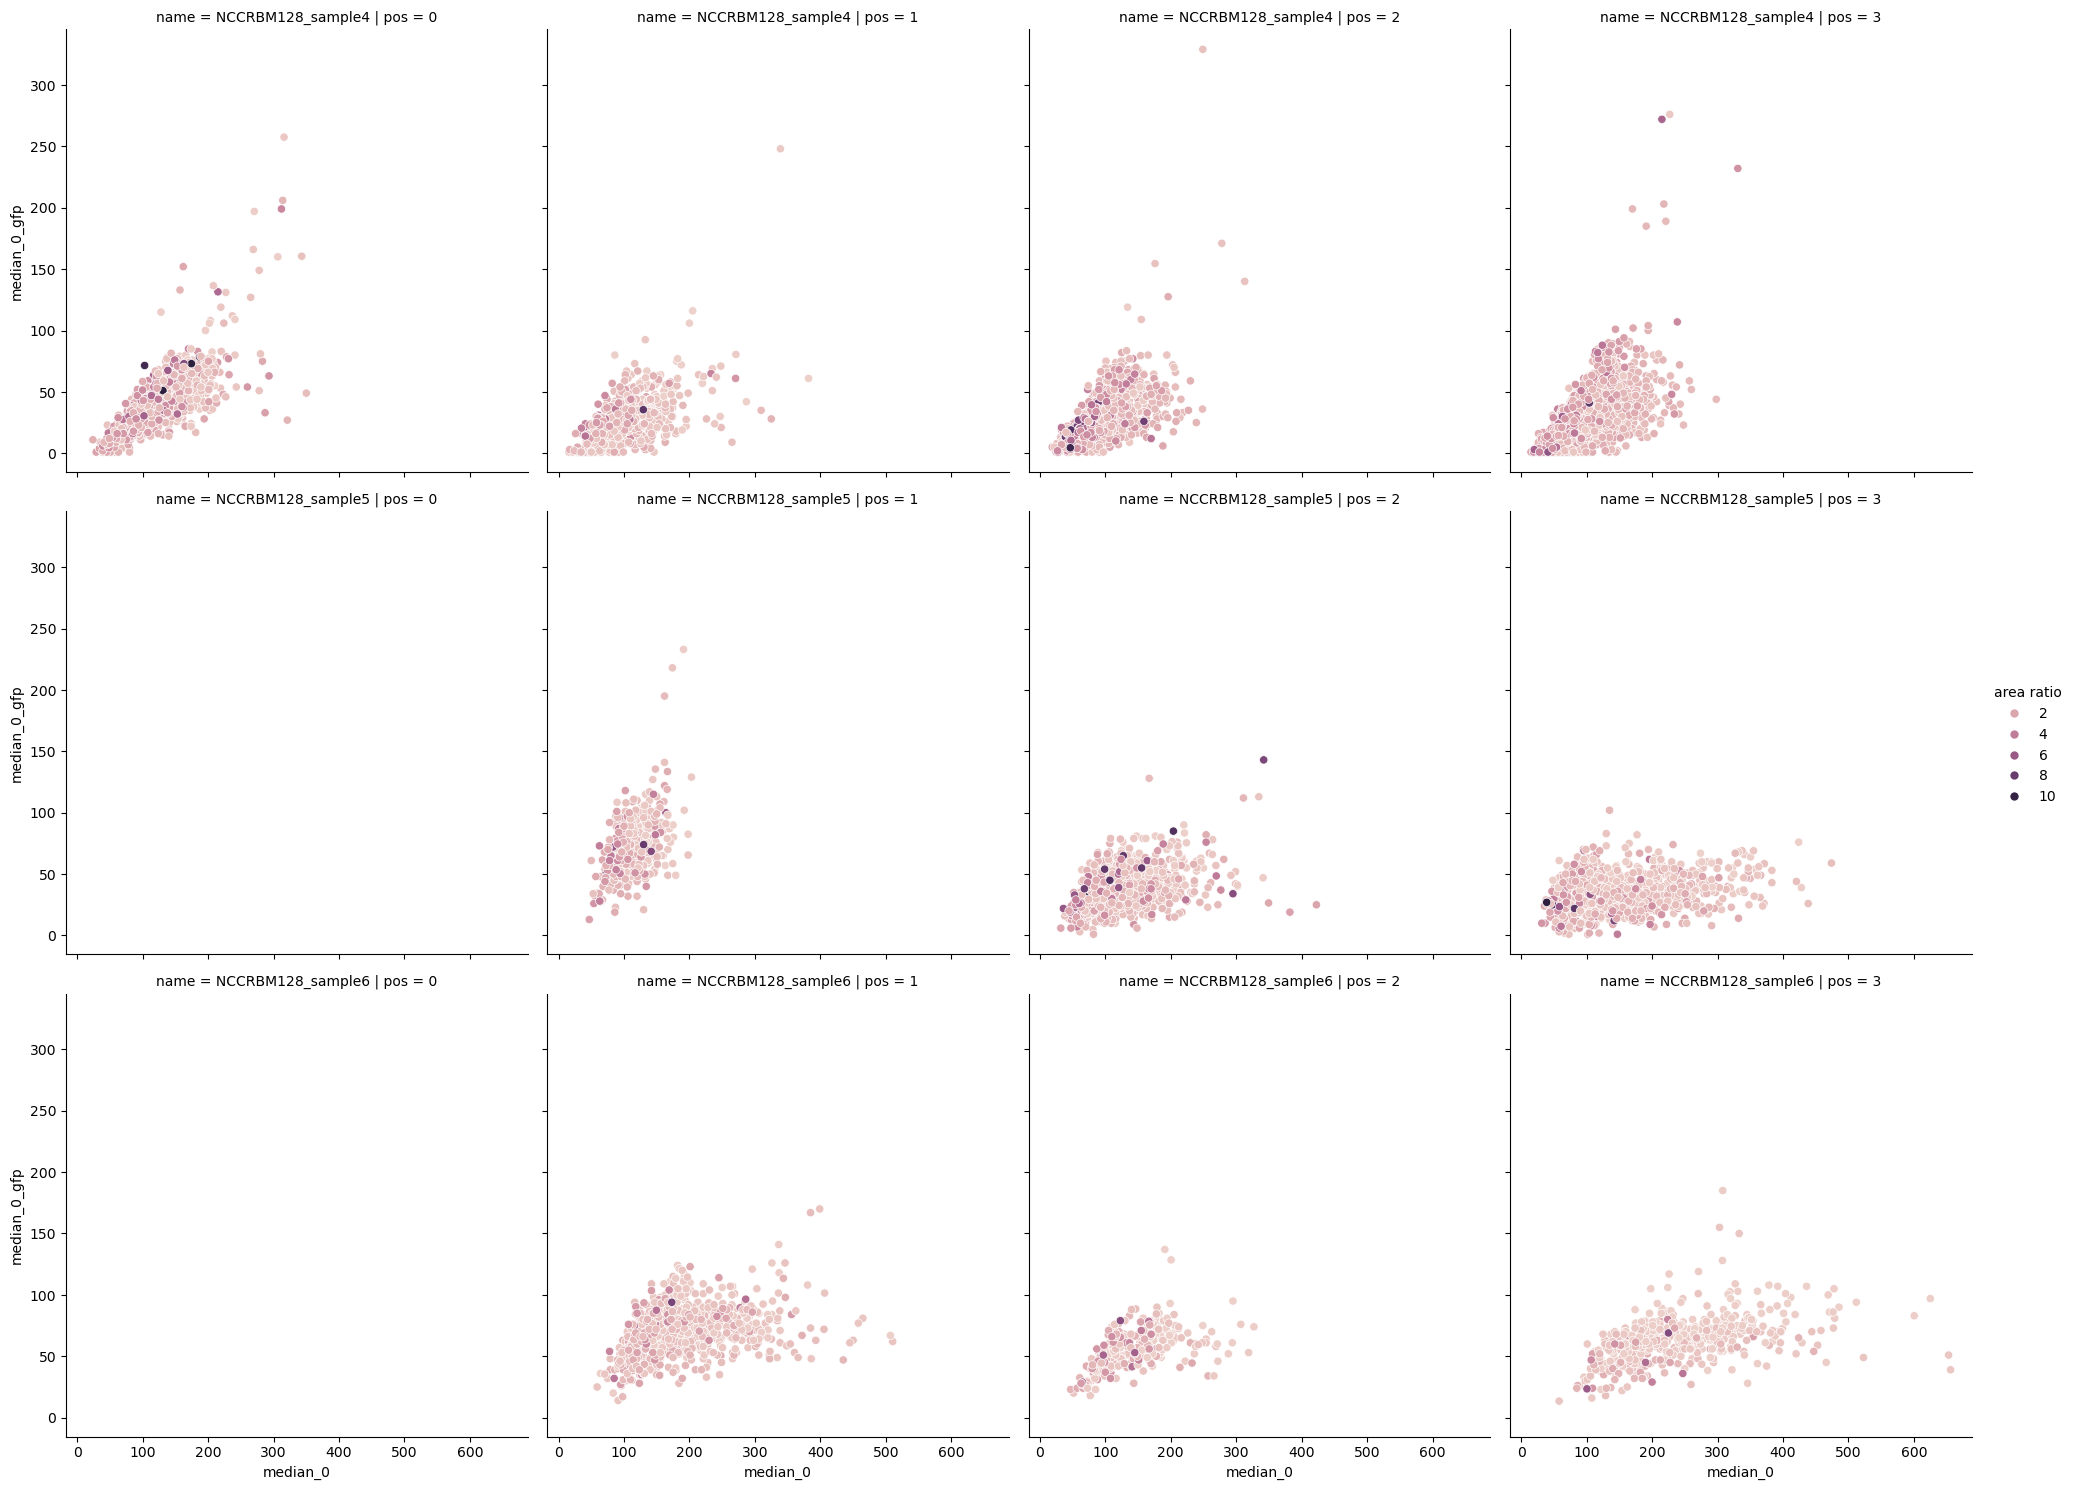

In [237]:
sns.relplot(
    tmp_df,
    x="median_0",
    y="median_0_gfp",
    hue="area ratio",
    row="name",
    col="pos",
)

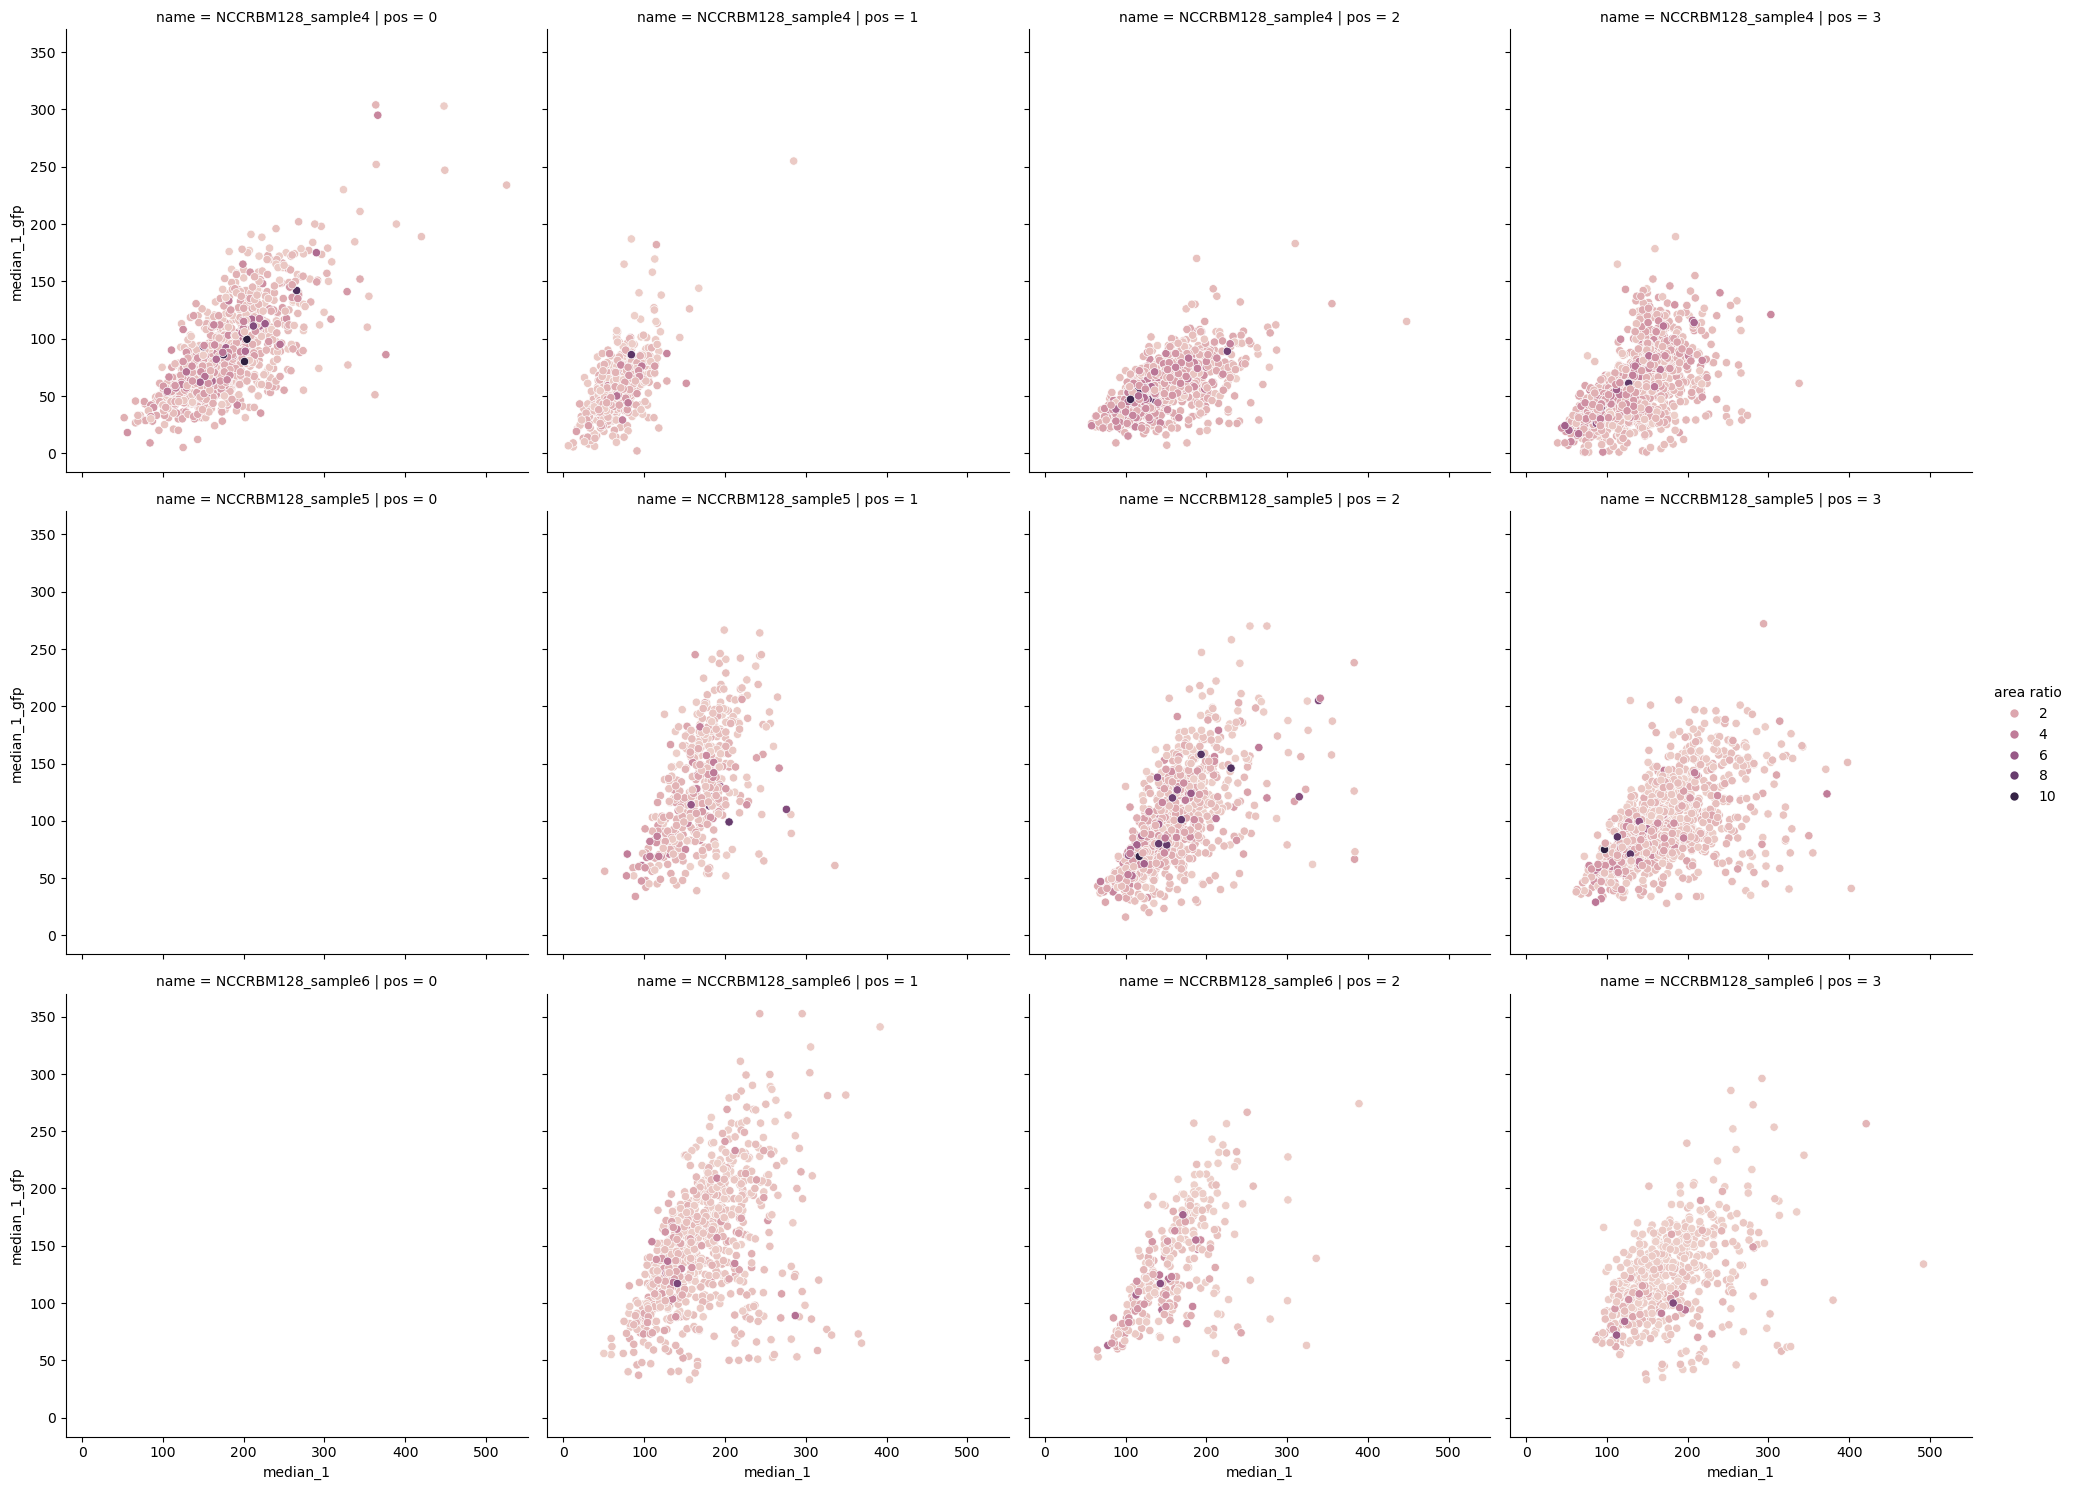

In [238]:
sns.relplot(
    tmp_df,
    x="median_1",
    y="median_1_gfp",
    hue="area ratio",
    row="name",
    col="pos",
)

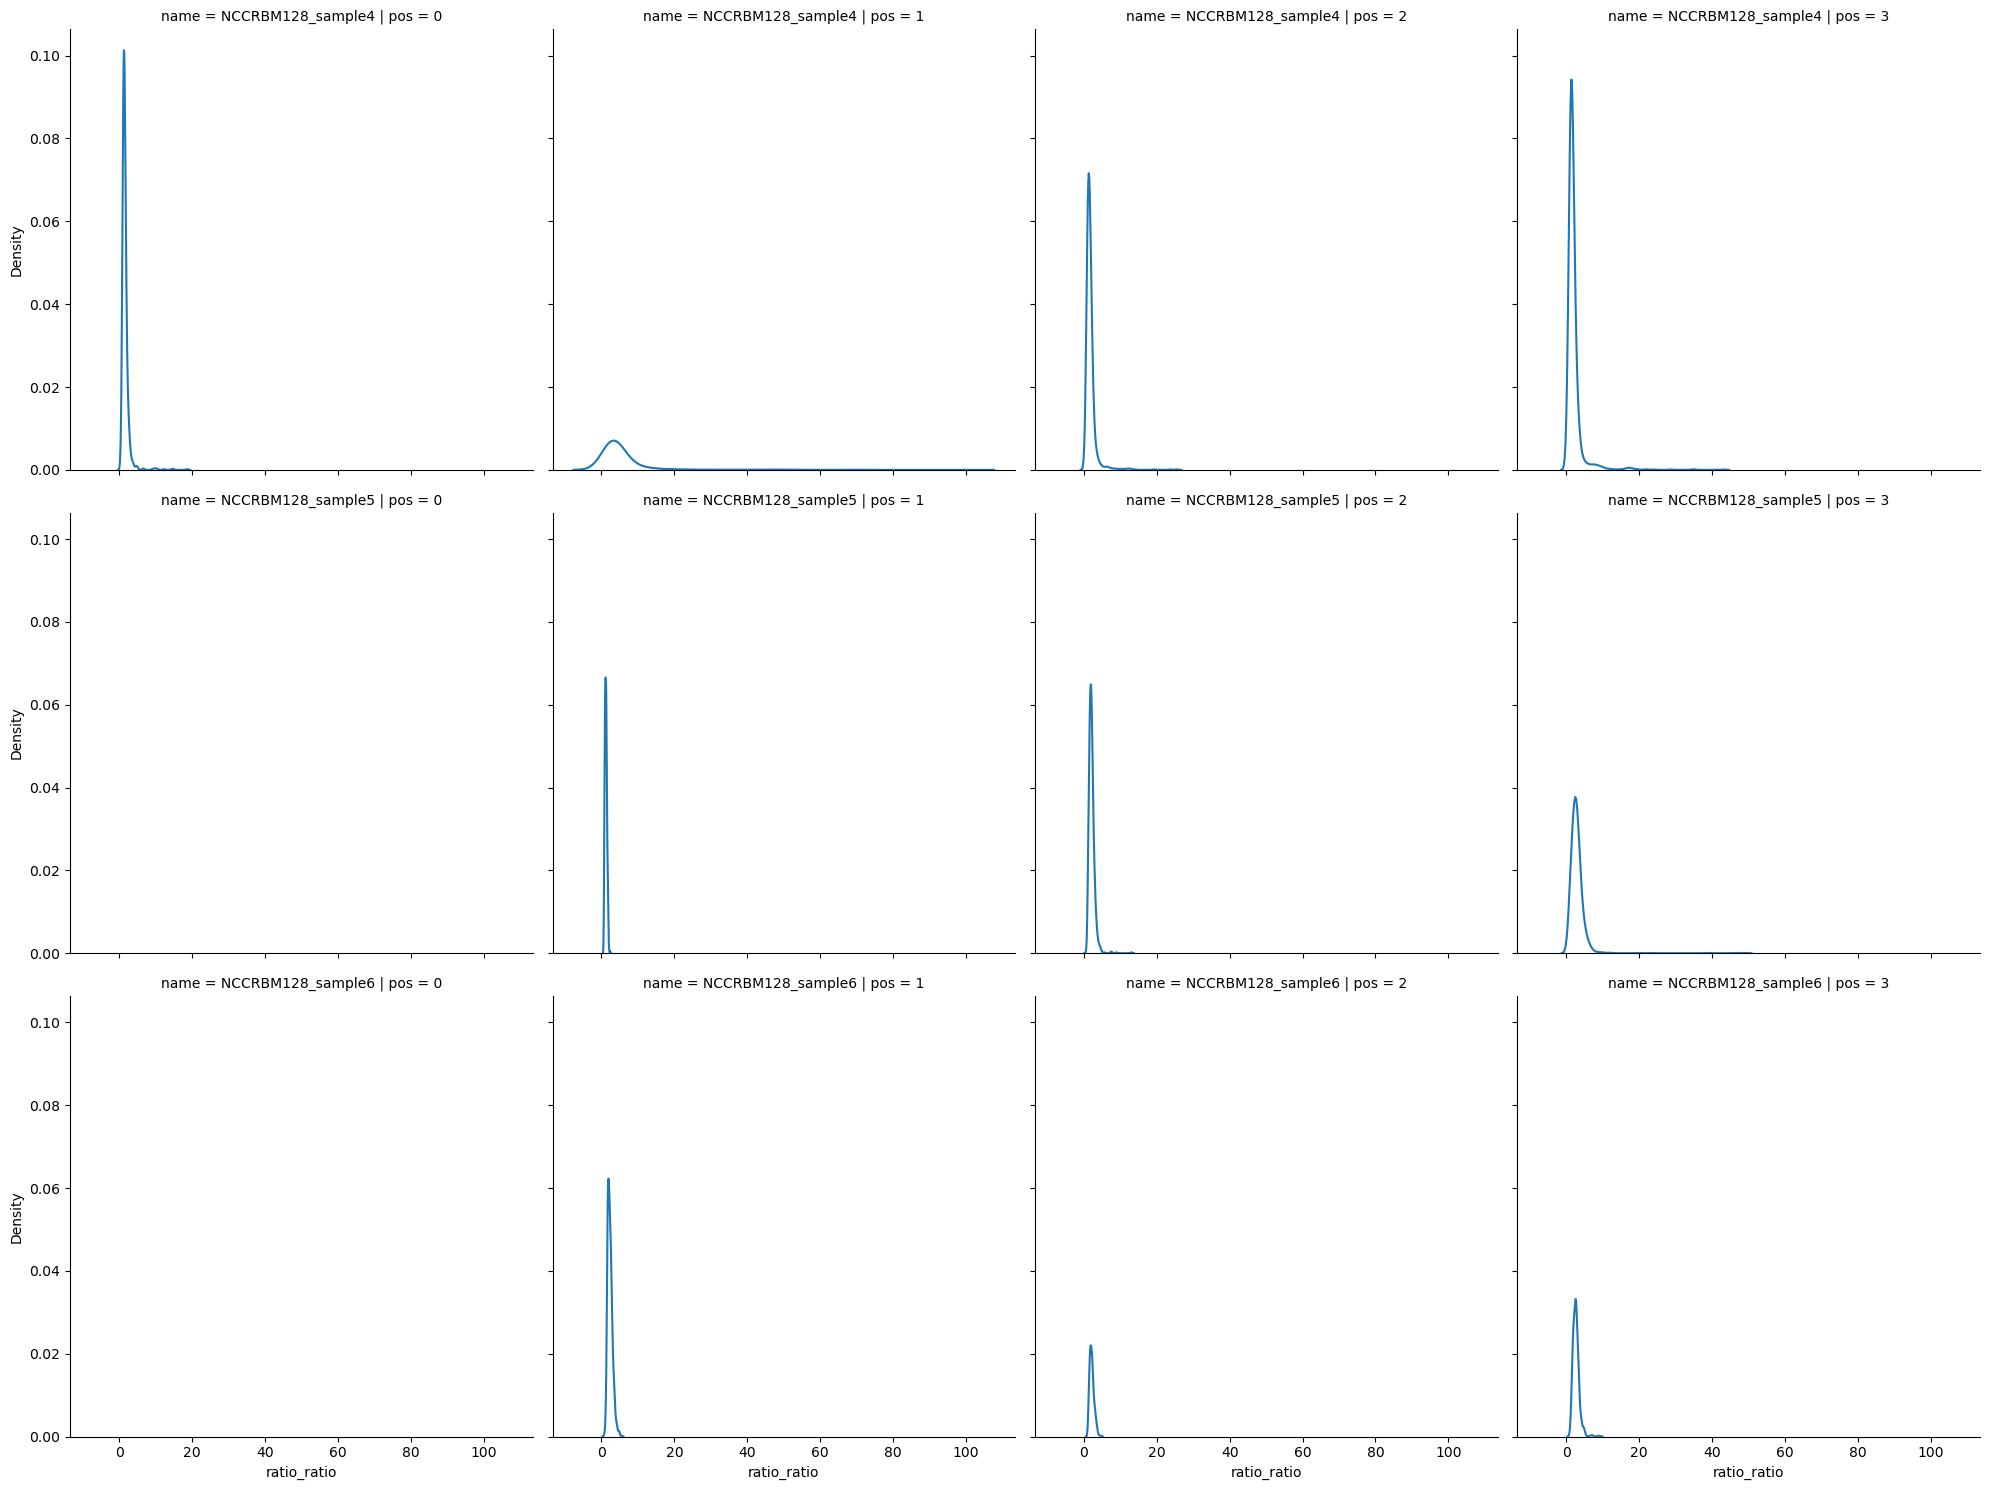

In [239]:
sns.displot(
    tmp_df,
    x="ratio_ratio",
    row="name",
    col="pos",
    kind="kde",
)

(-1.5, 5.0)

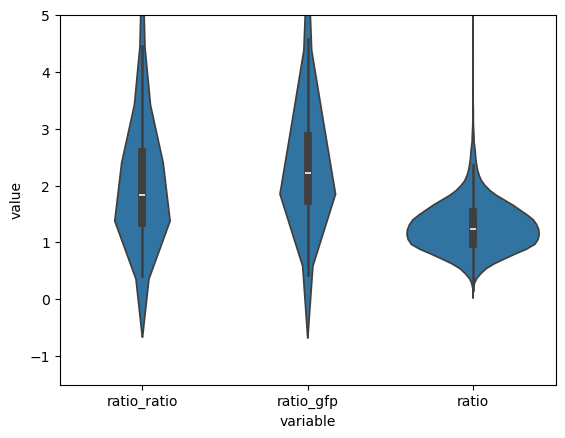

In [240]:
df_melt = tmp_df.melt(id_vars=["lbl_id", "name", "pos"], value_vars=["ratio_ratio", "ratio_gfp", "ratio"])

sns.violinplot(
    df_melt,
    x="variable",
    y="value",
)

ax = plt.gca()
ax.set_ylim(-1.5, 5)

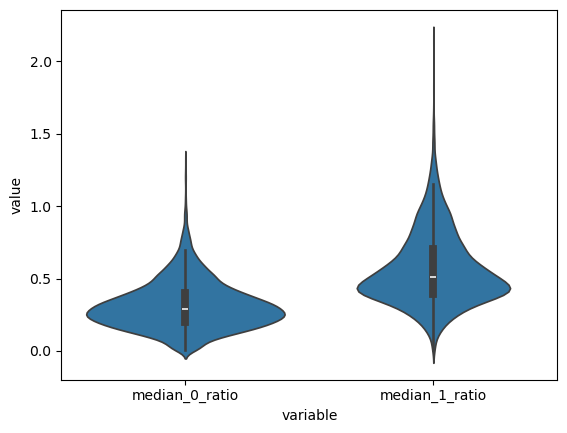

In [272]:
df_melt2 = tmp_df.melt(id_vars=["lbl_id", "name", "pos"], value_vars=["median_0_ratio", "median_1_ratio"])

sns.violinplot(
    df_melt2,
    x="variable",
    y="value",
)

with open(os.path.join(path, "results", "ratios.txt"), "w") as f:
    with redirect_stdout(f):
        plot_stats(tmp_df, ["median_0_ratio", "median_1_ratio"])

plt.savefig(os.path.join(path, "results", "ratios.svg"))
df_melt2.to_excel(os.path.join(path, "results", "ratios.xlsx"))

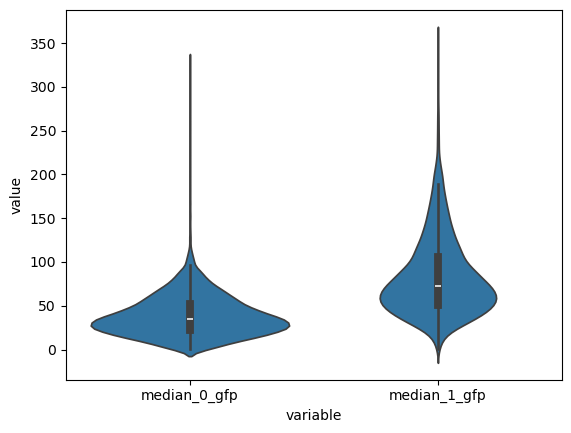

In [273]:
df_melt2 = tmp_df.melt(id_vars=["lbl_id", "name", "pos"], value_vars=["median_0_gfp", "median_1_gfp"])

sns.violinplot(
    df_melt2,
    x="variable",
    y="value",
)

with open(os.path.join(path, "results", "gfp.txt"), "w") as f:
    with redirect_stdout(f):
        plot_stats(tmp_df, ["median_0_gfp", "median_1_gfp"])

plt.savefig(os.path.join(path, "results", "gfp.svg"))
df_melt2.to_excel(os.path.join(path, "results", "gfp.xlsx"))

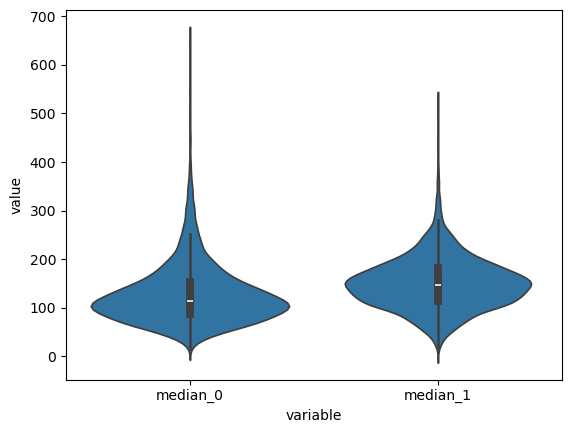

In [274]:
df_melt2 = tmp_df.melt(id_vars=["lbl_id", "name", "pos"], value_vars=["median_0", "median_1"])

sns.violinplot(
    df_melt2,
    x="variable",
    y="value",
)

def plot_stats(df, vals):
    for val in vals:
        print(val, "median:", np.median(df[val]), "iqr:", iqr(df[val]))
        print(val, "mean:", np.mean(df[val]), "std:", np.std(df[val]))

with open(os.path.join(path, "results", "mScarlett.txt"), "w") as f:
    with redirect_stdout(f):
        plot_stats(tmp_df, ["median_0", "median_1"])

plt.savefig(os.path.join(path, "results", "mScarlett.svg"))
df_melt2.to_excel(os.path.join(path, "results", "mScarlett.xlsx"))

(-1.5, 5.0)

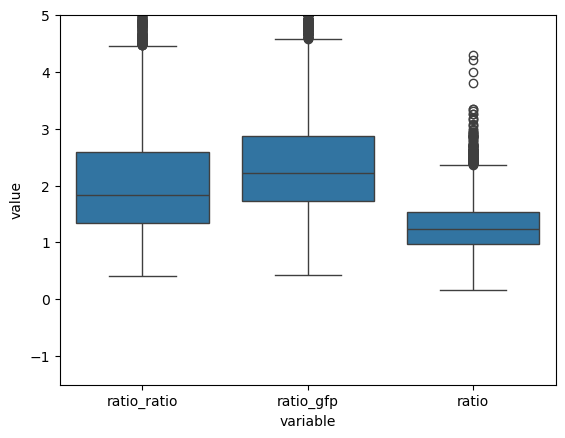

In [241]:
sns.boxplot(
    df_melt,
    x="variable",
    y="value",
)

ax = plt.gca()
ax.set_ylim(-1.5, 5)

<Axes: xlabel='area_0', ylabel='ratio_ratio'>

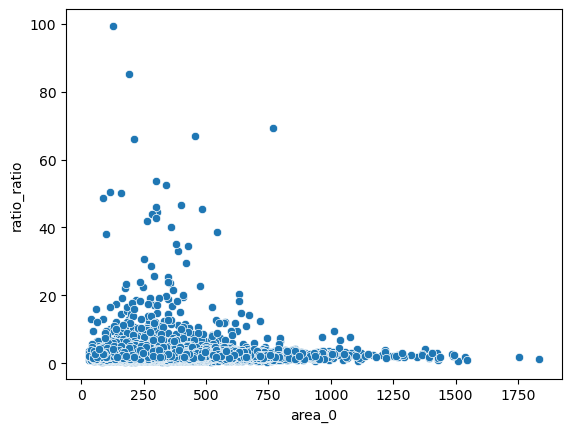

In [217]:
sns.scatterplot(
    all_df,
    x="area_0",
    y="ratio_ratio",
)

<Axes: xlabel='area_0', ylabel='area_1'>

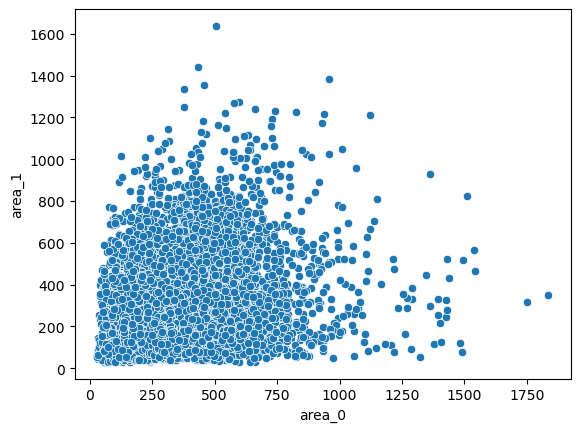

In [154]:
sns.scatterplot(
    all_df,
    x="area_0",
    y="area_1",
)

<Axes: xlabel='median_0_gfp', ylabel='Density'>

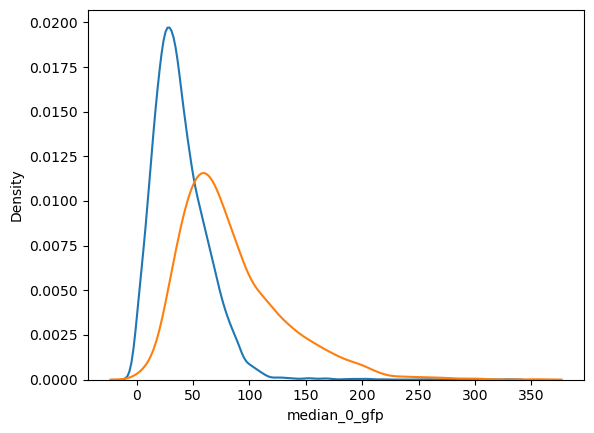

In [218]:
sns.kdeplot(tmp_df["median_0_gfp"])
sns.kdeplot(tmp_df["median_1_gfp"])

<Axes: xlabel='median_0', ylabel='Density'>

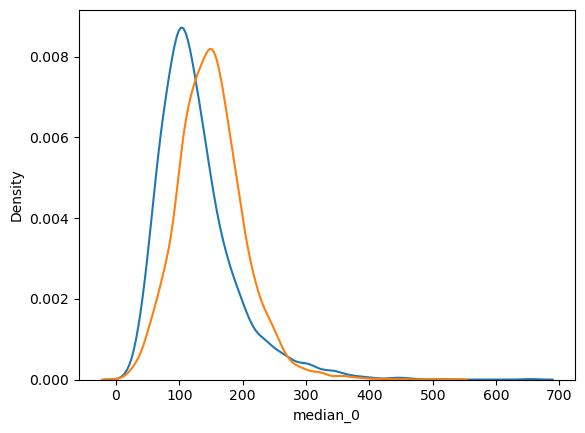

In [219]:
sns.kdeplot(tmp_df["median_0"])
sns.kdeplot(tmp_df["median_1"])

<Axes: xlabel='median_0_ratio', ylabel='Density'>

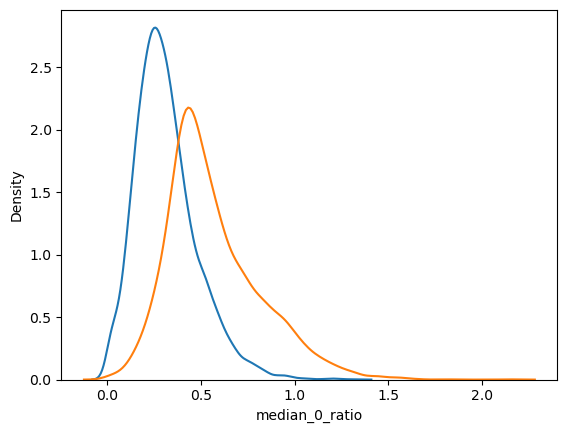

In [220]:
sns.kdeplot(tmp_df["median_0_ratio"])
sns.kdeplot(tmp_df["median_1_ratio"])

(-1.0, 3.0)

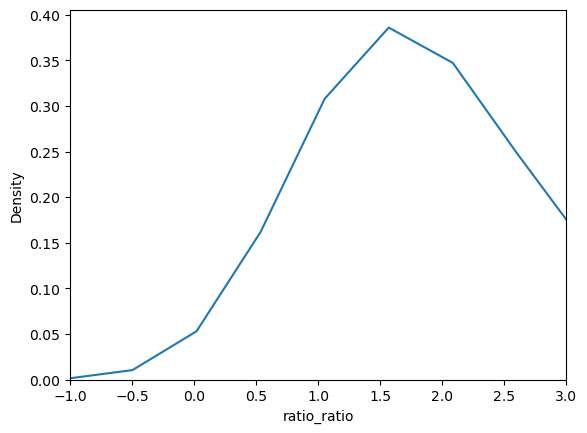

In [225]:
sns.kdeplot(tmp_df["ratio_ratio"])
ax = plt.gca()
ax.set_xlim(-1, 3)

In [248]:
np.median(tmp_df["median_1_ratio"]) / np.median(tmp_df["median_0_ratio"])

np.float64(1.7623556724180394)

In [247]:
np.median(tmp_df["median_1_gfp"]) / np.median(tmp_df["median_0_gfp"])

np.float64(2.085714285714286)

In [246]:
np.median(tmp_df["median_1_gfp"]), np.median(tmp_df["median_0_gfp"])

(np.float64(73.0), np.float64(35.0))